In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_blobs

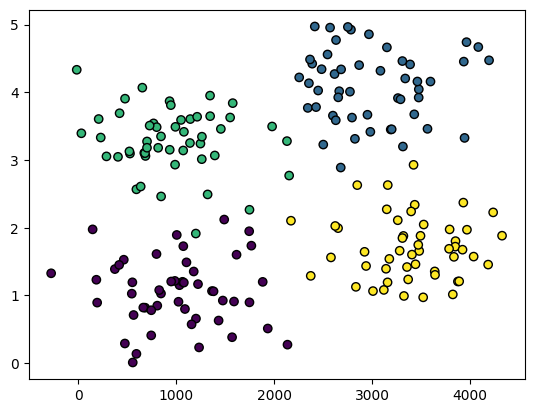

In [ ]:
blob_centers = ([1, 1], [3, 4], [1, 3.3], [3.5, 1.8])
X, y = make_blobs(n_samples=200,
                          centers=blob_centers,
                          cluster_std=0.5,
                          random_state=0)

X[:, 0] *= 1000

plt.scatter(X[:, 0], X[:, 1], c=y,  edgecolors='black',linewidth=1)

In [ ]:
from sklearn.neural_network import MLPClassifier

In [ ]:
clf = MLPClassifier(hidden_layer_sizes=(6,),
                    random_state=1).fit(X, y)

In [ ]:
print("Веса между входным и скрытым слоем:")
print(clf.coefs_[0])
print("\nВеса между скрытым и выходным слоем:")
print(clf.coefs_[1])

Веса между входным и скрытым слоем:
[[-0.09809877  0.33667051 -0.82024119 -0.29720839 -0.56852789 -0.66056109]
 [-0.58903611 -0.31219238 -0.22424296  0.11423652 -0.18324369  0.37321781]]

Веса между скрытым и выходным слоем:
[[-0.51316658 -0.43365467  0.43189995  0.68148414]
 [-0.24370005  0.34328608  0.57835494  0.57889271]
 [-0.59713359 -0.67678056 -0.46609801  0.54011704]
 [-0.5769702  -0.10221922  0.75476969  0.00610289]
 [ 0.34285864 -0.25645017  0.33417991  0.47281254]
 [-0.7006119   0.35515533  0.80295119  0.33880635]]


In [ ]:
for i in range(len(clf.coefs_)):
    number_neurons_in_layer = clf.coefs_[i].shape[1]
    for j in range(number_neurons_in_layer):
        weights = clf.coefs_[i][:,j]
        print(i + 1, j+1, weights, end=", ")
        print()
    print()

1 1 [-0.09809877 -0.58903611], 
1 2 [ 0.33667051 -0.31219238], 
1 3 [-0.82024119 -0.22424296], 
1 4 [-0.29720839  0.11423652], 
1 5 [-0.56852789 -0.18324369], 
1 6 [-0.66056109  0.37321781], 

2 1 [-0.51316658 -0.24370005 -0.59713359 -0.5769702   0.34285864 -0.7006119 ], 
2 2 [-0.43365467  0.34328608 -0.67678056 -0.10221922 -0.25645017  0.35515533], 
2 3 [ 0.43189995  0.57835494 -0.46609801  0.75476969  0.33417991  0.80295119], 
2 4 [0.68148414 0.57889271 0.54011704 0.00610289 0.47281254 0.33880635], 



In [ ]:
print("Веса смещения для скрытого слоя:")
print(clf.intercepts_[0])
print("\nВеса смещения для выходного слоя:")
print(clf.intercepts_[1])

Веса смещения для скрытого слоя:
[-0.55752645  0.60978582 -0.8640854   0.33258994 -0.18652436  0.05696655]

Веса смещения для выходного слоя:
[-0.29413473  0.49414359 -0.60792984 -0.11888525]


In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score

In [ ]:
confusion_matrix(y, clf.predict(X))

array([[ 0,  0,  0, 50],
       [ 0,  0,  0, 50],
       [ 0,  0,  0, 50],
       [ 0,  0,  0, 50]])

In [ ]:
accuracy_score(y, clf.predict(X))

0.25

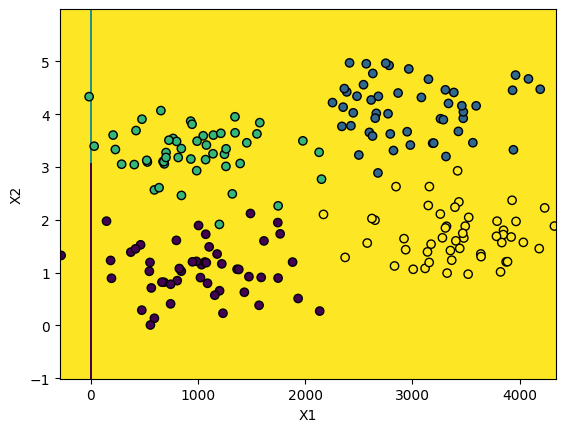

In [ ]:
X0 = np.linspace(X[:, 0].min()-1,X[:, 0].max()+1, X.shape[0])
X1 = np.linspace(X[:, 1].min()-1,X[:, 1].max()+1, X.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)

y_predict = clf.predict(np.c_[X0_grid.ravel(),X1_grid.ravel()]).reshape(X0_grid.shape)
plt.pcolormesh(X0_grid, X1_grid, y_predict)

plt.scatter(X[:, 0], X[:, 1], c=y,  edgecolors='black',linewidth=1)
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
X_scaled = StandardScaler().fit_transform(X)

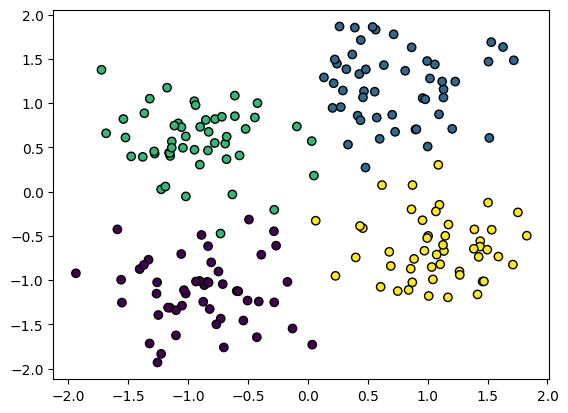

In [ ]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y,  edgecolors='black',linewidth=1)

In [ ]:
clf = MLPClassifier(hidden_layer_sizes=(6,),
                    random_state=1).fit(X_scaled, y)

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
accuracy_score(y, clf.predict(X_scaled))

0.75

In [ ]:
confusion_matrix(y, clf.predict(X_scaled))

array([[22,  0, 11, 17],
       [ 0, 38,  0, 12],
       [ 0,  3, 45,  2],
       [ 0,  5,  0, 45]])

In [ ]:
X = X_scaled

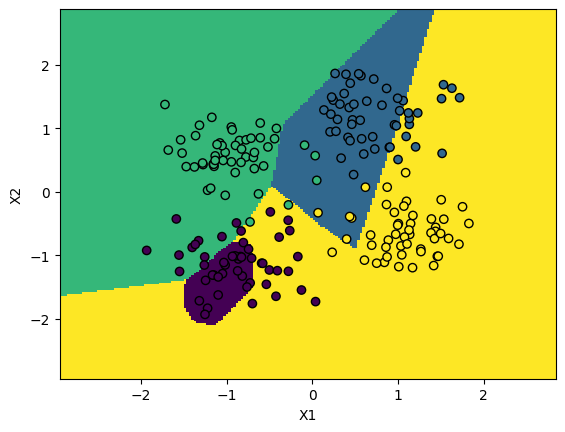

In [ ]:
X0 = np.linspace(X[:, 0].min()-1,X[:, 0].max()+1, X.shape[0])
X1 = np.linspace(X[:, 1].min()-1,X[:, 1].max()+1, X.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)

y_predict = clf.predict(np.c_[X0_grid.ravel(),X1_grid.ravel()]).reshape(X0_grid.shape)
plt.pcolormesh(X0_grid, X1_grid, y_predict)

plt.scatter(X[:, 0], X[:, 1], c=y,  edgecolors='black',linewidth=1)
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

In [ ]:
clf = MLPClassifier(hidden_layer_sizes=(100,100,50),
                    random_state=1, max_iter = 10000).fit(X_scaled, y)

In [ ]:
accuracy_score(y, clf.predict(X_scaled))

0.99

In [ ]:
confusion_matrix(y, clf.predict(X_scaled))

array([[49,  0,  1,  0],
       [ 0, 50,  0,  0],
       [ 1,  0, 49,  0],
       [ 0,  0,  0, 50]])

In [ ]:
X = X_scaled

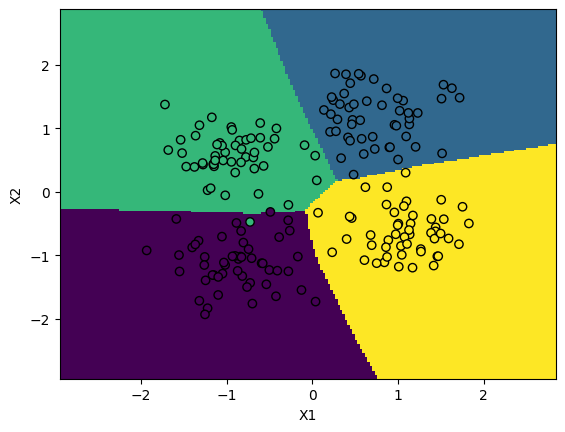

In [ ]:
X0 = np.linspace(X[:, 0].min()-1,X[:, 0].max()+1, X.shape[0])
X1 = np.linspace(X[:, 1].min()-1,X[:, 1].max()+1, X.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)

y_predict = clf.predict(np.c_[X0_grid.ravel(),X1_grid.ravel()]).reshape(X0_grid.shape)
plt.pcolormesh(X0_grid, X1_grid, y_predict)

plt.scatter(X[:, 0], X[:, 1], c=y,  edgecolors='black',linewidth=1)
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

Создайте однослойный перцептрон с 1, 2, 10 и 100 нейронами. Сравние их точность и сделайте вывод о достаточном количестве нейронов.

In [ ]:
accuracies = {}
neurons = [1, 2, 10, 100]

for n in neurons:
    clf = MLPClassifier(hidden_layer_sizes=(n,), random_state=1)
    clf.fit(X_scaled, y)  # Обучение модели
    y_pred = clf.predict(X_scaled)
    accuracy = accuracy_score(y, y_pred)  # Оценка точности
    accuracies[n] = accuracy
    print(f"Точность модели с {n} нейронами: {accuracy}")

# Печать результатов
print("\nСравнение точности моделей с разным количеством нейронов:")
for n, acc in accuracies.items():
    print(f"{n} нейронов: {acc}")


Точность модели с 1 нейронами: 0.25
Точность модели с 2 нейронами: 0.44


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Точность модели с 10 нейронами: 0.825
Точность модели с 100 нейронами: 0.98

Сравнение точности моделей с разным количеством нейронов:
1 нейронов: 0.25
2 нейронов: 0.44
10 нейронов: 0.825
100 нейронов: 0.98


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Создайте и оцените модель с двумя, тремя и десятью скрытыми слоями с одинаковым количеством нейронов. Сравните их точность и сделайте вывод о достаточном количестве слоев.

In [ ]:
# Список количества слоев
layers = [2, 3, 10]

for layers_num in layers:
    clf = MLPClassifier(hidden_layer_sizes=(6,) * layers_num, random_state=1)
    clf.fit(X_scaled, y)  # Обучение модели
    y_pred = clf.predict(X_scaled)
    accuracy = accuracy_score(y, y_pred)  # Оценка точности
    print(f"Точность модели с {layers_num} скрытыми слоями: {accuracy}")


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Точность модели с 2 скрытыми слоями: 0.79
Точность модели с 3 скрытыми слоями: 0.8
Точность модели с 10 скрытыми слоями: 0.49


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Для глубокой модели выведите веса всех нейронов на всех слоях. Выведите значения векторов весов смещения.

In [ ]:
# Обучаем модель с 3 слоями и 6 нейронами в каждом
clf = MLPClassifier(hidden_layer_sizes=(6, 6, 6), random_state=1)
clf.fit(X_scaled, y)

# Вывод весов
print("Веса между входным и скрытым слоем:")
print(clf.coefs_[0])
print("\nВеса между скрытыми и выходным слоем:")
print(clf.coefs_[1])

# Веса смещения
print("\nВеса смещения для скрытого слоя:")
print(clf.intercepts_[0])
print("\nВеса смещения для выходного слоя:")
print(clf.intercepts_[1])

# Вывод весов для каждого слоя
for i in range(len(clf.coefs_)):
    number_neurons_in_layer = clf.coefs_[i].shape[1]
    for j in range(number_neurons_in_layer):
        weights = clf.coefs_[i][:, j]
        print(f"Слой {i+1}, Нейрон {j+1}: {weights}")
    print()


Веса между входным и скрытым слоем:
[[-0.39254317  0.6240117  -0.9423812  -0.2982073  -0.68112795 -0.81593564]
 [-0.76590896 -0.10528184 -0.24713491  0.17574473 -0.10671224  0.14676414]]

Веса между скрытыми и выходным слоем:
[[-0.6725401  -0.28778402  0.27416141  0.86597958 -0.3980926   0.10617231]
 [ 0.58597176  0.81602707 -0.42410424 -0.44793492 -0.5213587   0.6281284 ]
 [-0.60065205 -0.11091993  0.48176726  0.27654997  0.17298679 -0.33319172]
 [ 0.42816757  0.45713813 -0.51396809  0.61740671  0.69299923  0.25742372]
 [-0.50544213  0.36475118 -0.39985484  0.22360251  0.52942119 -0.40828992]
 [-0.50512876 -0.57910861 -0.51250722  0.5252467  -0.39414585 -0.45830516]]

Веса смещения для скрытого слоя:
[-0.25802401  0.6144926  -0.69499936  0.27755895 -0.00719214  0.21719962]

Веса смещения для выходного слоя:
[ 0.13337428 -0.37531644  0.10481812 -0.19336562  0.10515161  0.20162597]
Слой 1, Нейрон 1: [-0.39254317 -0.76590896]
Слой 1, Нейрон 2: [ 0.6240117  -0.10528184]
Слой 1, Нейрон 3: 

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Постройте и оцените модель с большим количеством нейронов и слоев. Замерьте время выполнения обучения, сравните со временем обучения более простых моделей.

In [ ]:
import time

# Модель с большим количеством нейронов и слоев
clf = MLPClassifier(hidden_layer_sizes=(100, 100, 100, 100), random_state=1)

# Замер времени обучения
start_time = time.time()
clf.fit(X_scaled, y)
end_time = time.time()

print(f"Время обучения модели с 4 слоями по 100 нейронов: {end_time - start_time} секунд")
clf = MLPClassifier(hidden_layer_sizes=(6,), random_state=1)

# Замер времени обучения
start_time = time.time()
clf.fit(X_scaled, y)
end_time = time.time()

print(f"Время обучения модели с 1 слоем по 6 нейронов: {end_time - start_time} секунд")

Время обучения модели с 4 слоями по 100 нейронов: 2.4325144290924072 секунд
Время обучения модели с 1 слоем по 6 нейронов: 0.289046049118042 секунд


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Постройте и оцените модель классификации с помощью перцептрона на датасете, который вы использовали на контрольной по классификиации (если вы ее не выполняли, возьмите любой датасет из раздела "real world datasets" в библиотеке sklearn).

In [ ]:
from sklearn.datasets import make_classification


# Генерация нового классификационного датасета
X, y = make_classification(n_samples=200, n_features=2, n_informative=2,
                           n_redundant=0, n_repeated=0, random_state=0)

# Масштабирование данных
X_scaled = StandardScaler().fit_transform(X)

# Обучение модели
clf = MLPClassifier(hidden_layer_sizes=(6,), random_state=1)
clf.fit(X_scaled, y)

# Оценка точности
accuracy = accuracy_score(y, clf.predict(X_scaled))
print(f"Точность модели на новом датасете: {accuracy}")



Точность модели на новом датасете: 0.66


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Постройте и оцените модель регрессии с помощью перцептрона на датасете, который вы использовали на контрольной по регрессии.

In [ ]:
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error
from sklearn.neural_network import MLPRegressor  # Импортируем MLPRegressor
# Генерация датасета для регрессии
X, y = make_regression(n_samples=200, n_features=2, noise=0.1, random_state=0)

# Масштабирование данных
X_scaled = StandardScaler().fit_transform(X)

# Обучение модели регрессии
clf = MLPRegressor(hidden_layer_sizes=(6,), random_state=1)
clf.fit(X_scaled, y)

# Предсказания и оценка
y_pred = clf.predict(X_scaled)
mse = mean_squared_error(y, y_pred)
print(f"Среднеквадратическая ошибка модели регрессии: {mse}")


Среднеквадратическая ошибка модели регрессии: 1406.911433566024


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
